<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/2_Chapter_2_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pemodelan Supervised Learning & Evaluasi Algoritma Klasifikasi dan Regresi

Notebook ini menyajikan implementasi praktis dan penjelasan teoritis dari algoritma-algoritma kunci dalam *Supervised Learning* (Pembelajaran Terbimbing) berdasarkan Bab 2 buku *"Introduction to Machine Learning with Python"* (Müller & Guido). Kita akan mengeksplorasi KNN, Model Linier, Decision Trees, Random Forests, dan Support Vector Machines (SVM).

## Bagian 1: Konsep Dasar Generalisasi & Dataset Uji

Dalam pembelajaran terbimbing, kita melatih model pada data latih dengan harapan model dapat melakukan prediksi secara tepat pada data baru yang belum pernah dilihat sebelumnya (kemampuan **generalisasi**).
- **Overfitting**: Model terlalu sensitif terhadap data latih (menghafal detail/derau) sehingga gagal memprediksi data uji dengan baik.
- **Underfitting**: Model terlalu sederhana untuk menangkap pola penting pada data latih, sehingga akurasinya rendah baik di data latih maupun uji.

Di bawah ini, kita mempersiapkan setup pustaka utama serta memuat dataset sintetis (`forge` dan `wave`) dan dataset riil (kanker payudara dan California Housing) sebagai basis eksperimen.

In [1]:
# Setup environment & install libraries jika diperlukan
!pip install mglearn seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mglearn

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

%matplotlib inline
sns.set_theme(style="whitegrid")
print("Semua pustaka utama berhasil dimuat.")


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Semua pustaka utama berhasil dimuat.


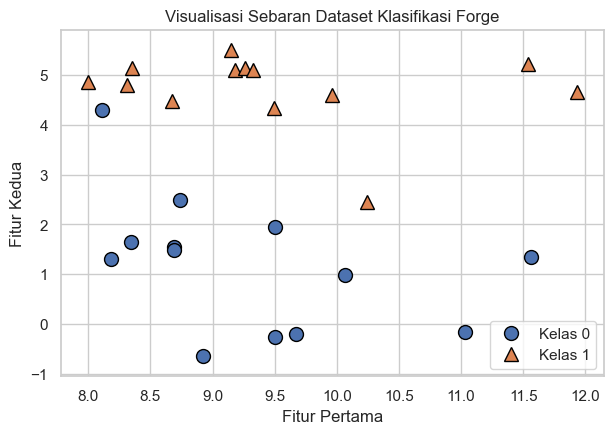

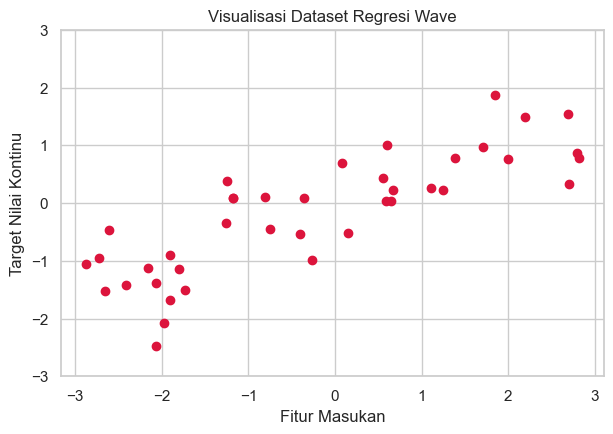

In [2]:
# 1. Dataset Sintetis Klasifikasi (Forge Dataset)
X_forge, y_forge = mglearn.datasets.make_forge()

plt.figure(figsize=(7, 4.5))
mglearn.discrete_scatter(X_forge[:, 0], X_forge[:, 1], y_forge)
plt.legend(["Kelas 0", "Kelas 1"], loc=4)
plt.title("Visualisasi Sebaran Dataset Klasifikasi Forge")
plt.xlabel("Fitur Pertama")
plt.ylabel("Fitur Kedua")
plt.show()

# 2. Dataset Sintetis Regresi (Wave Dataset)
X_wave, y_wave = mglearn.datasets.make_wave(n_samples=40)

plt.figure(figsize=(7, 4.5))
plt.plot(X_wave, y_wave, 'o', color='crimson')
plt.ylim(-3, 3)
plt.title("Visualisasi Dataset Regresi Wave")
plt.xlabel("Fitur Masukan")
plt.ylabel("Target Nilai Kontinu")
plt.show()

In [3]:
# 3. Dataset Kanker Payudara (Klasifikasi Riil)
kanker = load_breast_cancer()
print(f"Dataset Kanker Payudara - Dimensi Data: {kanker.data.shape}")
print(f"Distribusi kelas target: {dict(zip(kanker.target_names, np.bincount(kanker.target)))}")

# 4. Dataset Perumahan California (Regresi Riil - Alternatif Boston)
perumahan = fetch_california_housing()
print(f"\nDataset Perumahan California - Dimensi Data: {perumahan.data.shape}")

# Mengembangkan fitur menggunakan interaksi polinomial untuk mendemonstrasikan overfitting linier
fitur_polinomial = PolynomialFeatures(degree=2, include_bias=False)
X_perumahan_luas = fitur_polinomial.fit_transform(perumahan.data)
print(f"Dimensi data setelah ekspansi fitur polinomial (2 derajat): {X_perumahan_luas.shape}")

Dataset Kanker Payudara - Dimensi Data: (569, 30)
Distribusi kelas target: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}

Dataset Perumahan California - Dimensi Data: (20640, 8)
Dimensi data setelah ekspansi fitur polinomial (2 derajat): (20640, 44)


## Bagian 2: K-Nearest Neighbors (KNN)

Algoritma KNN mengklasifikasi titik data baru berdasarkan mayoritas label kelas dari tetangga terdekatnya ($K$). Di bagian ini, kita melihat bagaimana pemilihan nilai $K$ menentukan batas keputusan klasifikasi dan regresi.

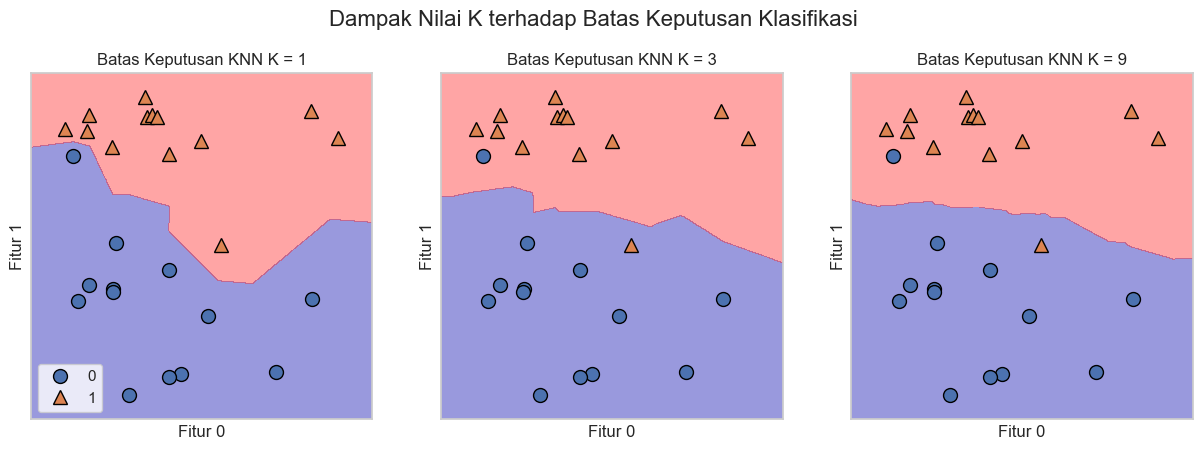

In [4]:
# Visualisasi batas keputusan KNN dengan berbagai tetangga (K = 1, 3, 9) pada Forge dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for k, ax in zip([1, 3, 9], axes):
    model_knn = KNeighborsClassifier(n_neighbors=k).fit(X_forge, y_forge)
    mglearn.plots.plot_2d_separator(model_knn, X_forge, fill=True, eps=0.5, ax=ax, alpha=.4)
    mglearn.discrete_scatter(X_forge[:, 0], X_forge[:, 1], y_forge, ax=ax)
    ax.set_title(f"Batas Keputusan KNN K = {k}")
    ax.set_xlabel("Fitur 0")
    ax.set_ylabel("Fitur 1")
axes[0].legend(loc=3)
plt.suptitle("Dampak Nilai K terhadap Batas Keputusan Klasifikasi", y=1.02, fontsize=16)
plt.show()

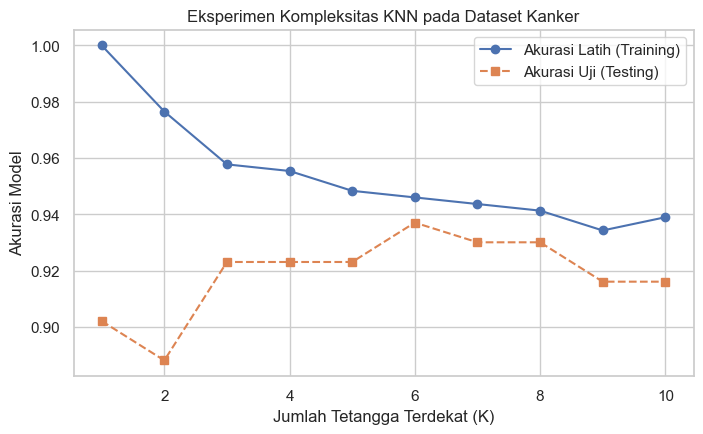

In [5]:
# Membagi dataset kanker
X_train_kanker, X_test_kanker, y_train_kanker, y_test_kanker = train_test_split(
    kanker.data, kanker.target, stratify=kanker.target, random_state=66
)

kurva_latih, kurva_uji = [], []
daftar_k = range(1, 11)

for k in daftar_k:
    clf = KNeighborsClassifier(n_neighbors=k).fit(X_train_kanker, y_train_kanker)
    kurva_latih.append(clf.score(X_train_kanker, y_train_kanker))
    kurva_uji.append(clf.score(X_test_kanker, y_test_kanker))

# Visualisasi performa latih vs uji (overfitting/underfitting)
plt.figure(figsize=(8, 4.5))
plt.plot(daftar_k, kurva_latih, label="Akurasi Latih (Training)", marker='o')
plt.plot(daftar_k, kurva_uji, label="Akurasi Uji (Testing)", marker='s', linestyle='--')
plt.xlabel("Jumlah Tetangga Terdekat (K)")
plt.ylabel("Akurasi Model")
plt.title("Eksperimen Kompleksitas KNN pada Dataset Kanker")
plt.legend()
plt.show()

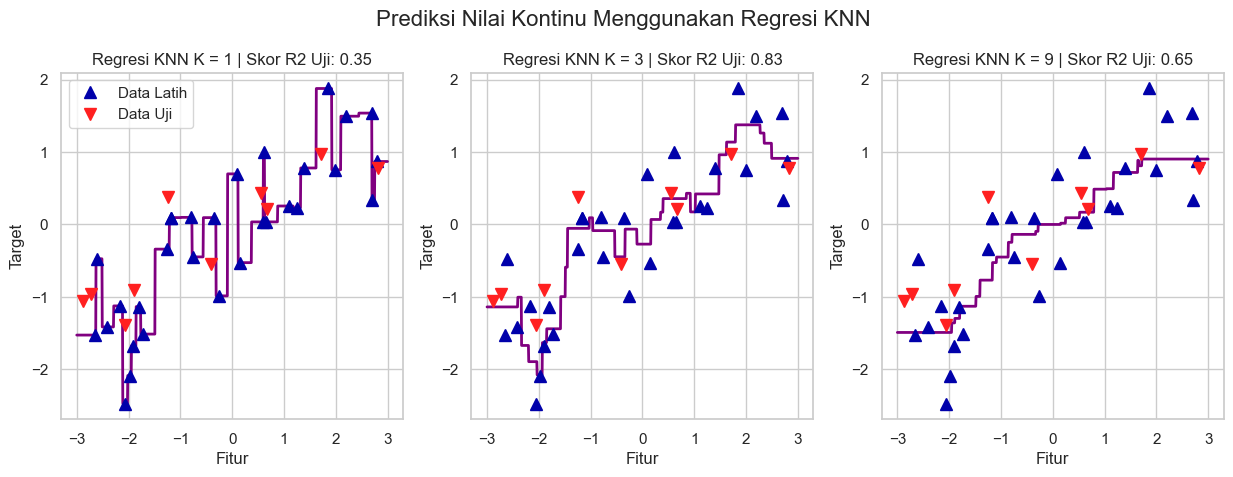

In [6]:
# KNN Regressor pada dataset Wave
X_train_wave, X_test_wave, y_train_wave, y_test_wave = train_test_split(
    X_wave, y_wave, random_state=0
)

# Membuat sumbu X kontinu untuk plotting prediksi
titik_prediksi = np.linspace(-3, 3, 1000).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for k, ax in zip([1, 3, 9], axes):
    reg_knn = KNeighborsRegressor(n_neighbors=k).fit(X_train_wave, y_train_wave)
    ax.plot(titik_prediksi, reg_knn.predict(titik_prediksi), color='purple', linewidth=2)
    ax.plot(X_train_wave, y_train_wave, '^', c=mglearn.cm2(0), markersize=8, label="Data Latih")
    ax.plot(X_test_wave, y_test_wave, 'v', c=mglearn.cm2(1), markersize=8, label="Data Uji")
    ax.set_title(f"Regresi KNN K = {k} | Skor R2 Uji: {reg_knn.score(X_test_wave, y_test_wave):.2f}")
    ax.set_xlabel("Fitur")
    ax.set_ylabel("Target")
axes[0].legend(loc="best")
plt.suptitle("Prediksi Nilai Kontinu Menggunakan Regresi KNN", y=1.02, fontsize=16)
plt.show()

## Bagian 3: Model Linier (Linear Models)

Model linier membuat prediksi menggunakan kombinasi linier dari fitur-fiturnya.
- **Regresi**: Linear Regression (OLS), Ridge (regulasi L2), dan Lasso (regulasi L1).
- **Klasifikasi**: Logistic Regression dan Linear Support Vector Machines (LinearSVC).

In [7]:
# Membagi dataset perumahan California hasil ekspansi polinomial
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_perumahan_luas, perumahan.target, random_state=42
)

# 1. Regresi Linier Standar (OLS) - Rentan Overfitting jika dimensi tinggi
model_ols = LinearRegression().fit(X_train_h, y_train_h)
print("=== Linear Regression (OLS) ===")
print(f"Skor R2 Latih : {model_ols.score(X_train_h, y_train_h):.4f}")
print(f"Skor R2 Uji   : {model_ols.score(X_test_h, y_test_h):.4f}")

# 2. Ridge Regression (L2 Regularization) - Mempersempit koefisien agar mendekati nol
model_ridge_1 = Ridge(alpha=1.0).fit(X_train_h, y_train_h)
model_ridge_10 = Ridge(alpha=10.0).fit(X_train_h, y_train_h)
model_ridge_01 = Ridge(alpha=0.1).fit(X_train_h, y_train_h)

print("\n=== Ridge Regression ===")
print(f"Ridge (alpha=1.0)  | R2 Latih: {model_ridge_1.score(X_train_h, y_train_h):.4f} | R2 Uji: {model_ridge_1.score(X_test_h, y_test_h):.4f}")
print(f"Ridge (alpha=10.0) | R2 Latih: {model_ridge_10.score(X_train_h, y_train_h):.4f} | R2 Uji: {model_ridge_10.score(X_test_h, y_test_h):.4f}")
print(f"Ridge (alpha=0.1)  | R2 Latih: {model_ridge_01.score(X_train_h, y_train_h):.4f} | R2 Uji: {model_ridge_01.score(X_test_h, y_test_h):.4f}")

=== Linear Regression (OLS) ===
Skor R2 Latih : 0.6304
Skor R2 Uji   : 0.5616

=== Ridge Regression ===
Ridge (alpha=1.0)  | R2 Latih: 0.6793 | R2 Uji: 0.6730
Ridge (alpha=10.0) | R2 Latih: 0.6732 | R2 Uji: 0.6620
Ridge (alpha=0.1)  | R2 Latih: 0.6814 | R2 Uji: 0.6790


c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.5761475255923084e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.839037528565584e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.082492416968169e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [8]:
# 3. Lasso Regression (L1 Regularization) - Mengeliminasi beberapa fitur (koefisien diatur menjadi tepat 0)
model_lasso_1 = Lasso(alpha=1.0).fit(X_train_h, y_train_h)
# Menggunakan alpha kecil dan menaikkan iterasi agar konvergen
model_lasso_001 = Lasso(alpha=0.01, max_iter=10000).fit(X_train_h, y_train_h)

print("=== Lasso Regression ===")
print(f"Lasso (alpha=1.0)   | R2 Latih: {model_lasso_1.score(X_train_h, y_train_h):.4f} | R2 Uji: {model_lasso_1.score(X_test_h, y_test_h):.4f}")
print(f"Jumlah fitur yang digunakan (Lasso alpha=1.0): {np.sum(model_lasso_1.coef_ != 0)}")

print(f"\nLasso (alpha=0.01)  | R2 Latih: {model_lasso_001.score(X_train_h, y_train_h):.4f} | R2 Uji: {model_lasso_001.score(X_test_h, y_test_h):.4f}")
print(f"Jumlah fitur yang digunakan (Lasso alpha=0.01): {np.sum(model_lasso_001.coef_ != 0)}")

c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.039394e+03, tolerance: 2.066e+00
  model = cd_fast.enet_coordinate_descent(


=== Lasso Regression ===
Lasso (alpha=1.0)   | R2 Latih: 0.6245 | R2 Uji: 0.6211
Jumlah fitur yang digunakan (Lasso alpha=1.0): 18

Lasso (alpha=0.01)  | R2 Latih: 0.6640 | R2 Uji: 0.6585
Jumlah fitur yang digunakan (Lasso alpha=0.01): 34


c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.507285e+03, tolerance: 2.066e+00
  model = cd_fast.enet_coordinate_descent(


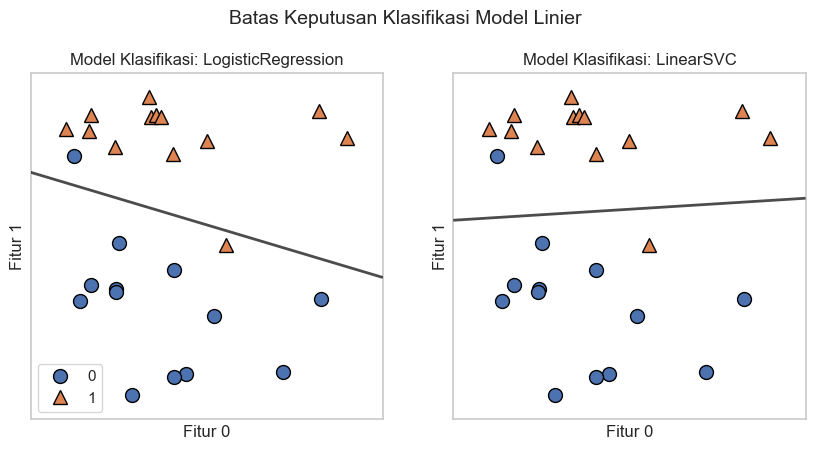

In [9]:
# Klasifikasi Linier pada dataset Forge menggunakan Logistic Regression & LinearSVC
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for model_class, ax in zip([LogisticRegression, LinearSVC], axes):
    clf = model_class(max_iter=5000).fit(X_forge, y_forge)
    mglearn.plots.plot_2d_separator(clf, X_forge, fill=False, eps=0.5, ax=ax, alpha=.7, linewidth=2)
    mglearn.discrete_scatter(X_forge[:, 0], X_forge[:, 1], y_forge, ax=ax)
    ax.set_title(f"Model Klasifikasi: {clf.__class__.__name__}")
    ax.set_xlabel("Fitur 0")
    ax.set_ylabel("Fitur 1")
axes[0].legend(loc=3)
plt.suptitle("Batas Keputusan Klasifikasi Model Linier", y=1.02, fontsize=14)
plt.show()

c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


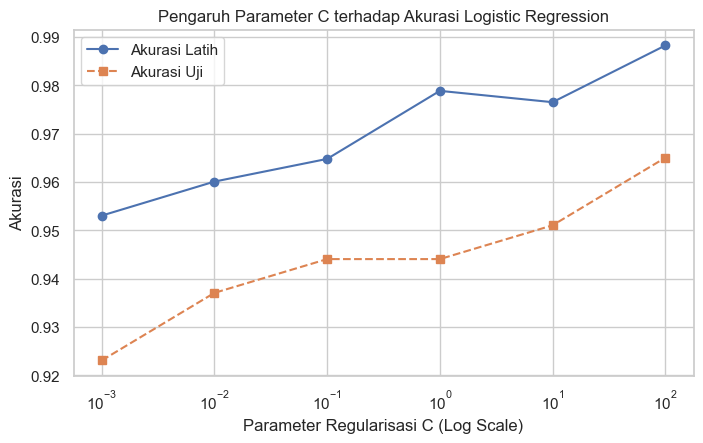

In [10]:
# Pengaruh parameter regulasi 'C' pada Logistic Regression (Dataset Kanker)
akurasi_latih_lr, akurasi_uji_lr = [], []
daftar_c = [0.001, 0.01, 0.1, 1, 10, 100]

for c in daftar_c:
    lr = LogisticRegression(C=c, max_iter=5000).fit(X_train_kanker, y_train_kanker)
    akurasi_latih_lr.append(lr.score(X_train_kanker, y_train_kanker))
    akurasi_uji_lr.append(lr.score(X_test_kanker, y_test_kanker))

# Plot perbandingan akurasi berdasarkan parameter C
plt.figure(figsize=(8, 4.5))
plt.semilogx(daftar_c, akurasi_latih_lr, label="Akurasi Latih", marker='o')
plt.semilogx(daftar_c, akurasi_uji_lr, label="Akurasi Uji", marker='s', linestyle='--')
plt.xlabel("Parameter Regularisasi C (Log Scale)")
plt.ylabel("Akurasi")
plt.title("Pengaruh Parameter C terhadap Akurasi Logistic Regression")
plt.legend()
plt.show()

## Bagian 4: Decision Trees & Random Forests

- **Decision Tree**: Membuat keputusan biner bercabang untuk mencapai klasifikasi. Rentan terhadap overfitting jika kedalaman pohon tidak dibatasi.
- **Random Forest**: Kumpulan pohon keputusan (*ensemble*) yang melatih setiap pohon secara acak lalu mengambil voting mayoritas hasil prediksi.

=== Decision Tree Tunggal ===
Akurasi Latih : 0.9883
Akurasi Uji   : 0.9021


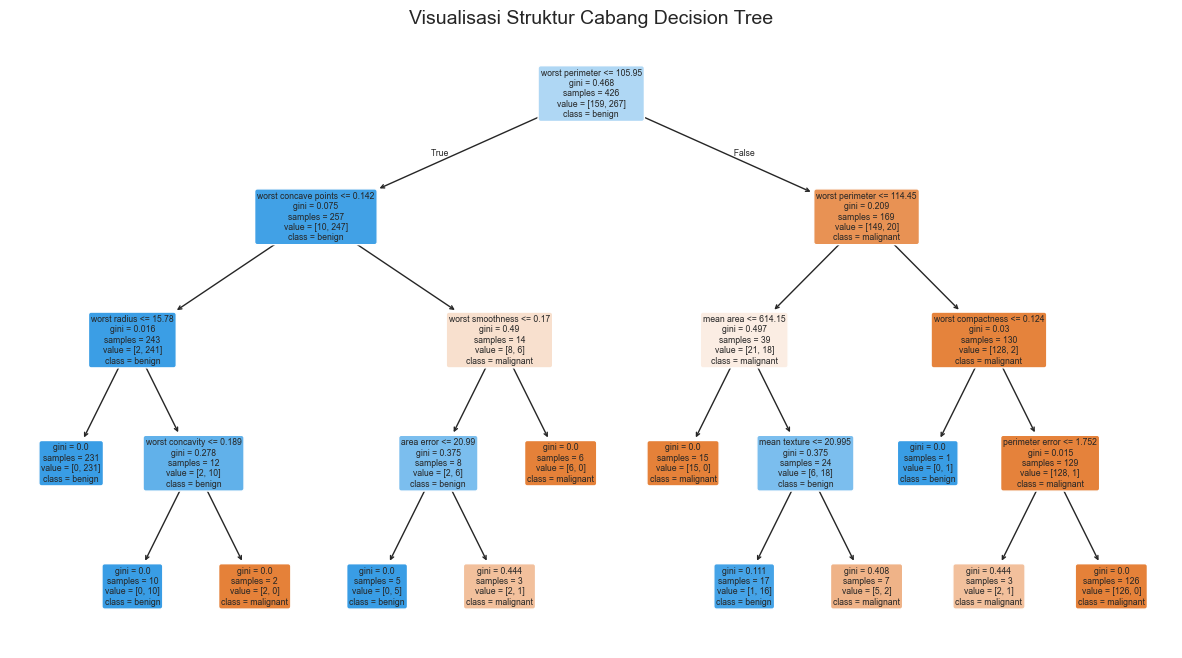

In [11]:
# Melatih Pohon Keputusan (Decision Tree) tunggal dengan batasan kedalaman max_depth=4
pohon = DecisionTreeClassifier(max_depth=4, random_state=0)
pohon.fit(X_train_kanker, y_train_kanker)

print("=== Decision Tree Tunggal ===")
print(f"Akurasi Latih : {pohon.score(X_train_kanker, y_train_kanker):.4f}")
print(f"Akurasi Uji   : {pohon.score(X_test_kanker, y_test_kanker):.4f}")

# Visualisasi Struktur Cabang Keputusan Pohon
plt.figure(figsize=(15, 8))
plot_tree(pohon, feature_names=kanker.feature_names, class_names=kanker.target_names, filled=True, rounded=True)
plt.title("Visualisasi Struktur Cabang Decision Tree", fontsize=14)
plt.show()

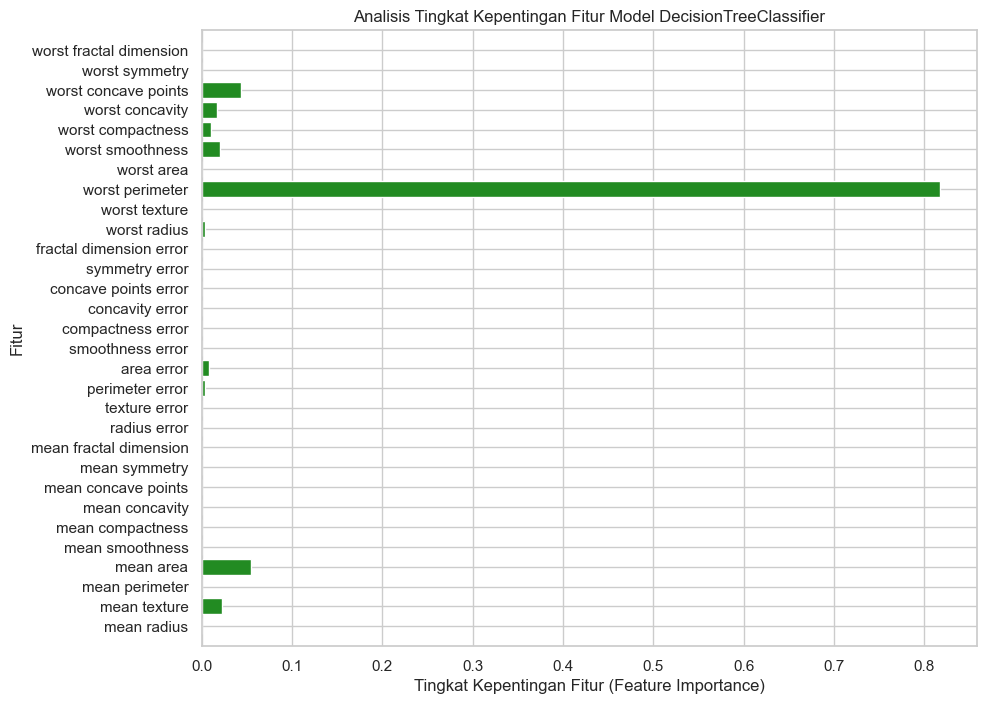

In [12]:
# Menampilkan tingkat kepentingan fitur (Feature Importance) dari Decision Tree
def visualisasi_feature_importances(model, dataset_raw):
    jumlah_fitur = dataset_raw.data.shape[1]
    plt.figure(figsize=(10, 8))
    plt.barh(range(jumlah_fitur), model.feature_importances_, align='center', color='forestgreen')
    plt.yticks(np.arange(jumlah_fitur), dataset_raw.feature_names)
    plt.xlabel("Tingkat Kepentingan Fitur (Feature Importance)")
    plt.ylabel("Fitur")
    plt.title(f"Analisis Tingkat Kepentingan Fitur Model {model.__class__.__name__}")
    plt.ylim(-1, jumlah_fitur)

visualisasi_feature_importances(pohon, kanker)
plt.show()

=== Random Forest Classifier ===
Akurasi Latih : 1.0000
Akurasi Uji   : 0.9580


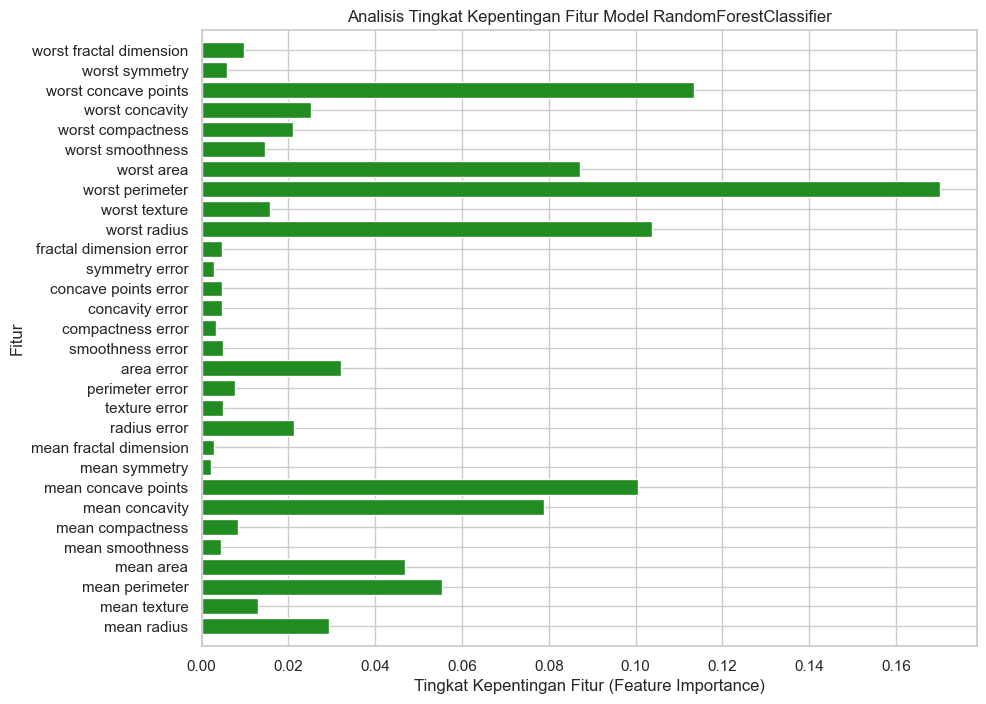

In [13]:
# Melatih model Random Forest (ensemble dari 100 pohon keputusan)
hutan = RandomForestClassifier(n_estimators=100, random_state=0).fit(X_train_kanker, y_train_kanker)

print("=== Random Forest Classifier ===")
print(f"Akurasi Latih : {hutan.score(X_train_kanker, y_train_kanker):.4f}")
print(f"Akurasi Uji   : {hutan.score(X_test_kanker, y_test_kanker):.4f}")

# Visualisasi tingkat kepentingan fitur pada model Random Forest
visualisasi_feature_importances(hutan, kanker)
plt.show()

## Bagian 5: Kernelized Support Vector Machines (SVM)

Support Vector Machines memproyeksikan data ke dimensi yang lebih tinggi menggunakan teknik Kernel (seperti RBF Kernel) agar batas pemisahan kelas non-linier menjadi linier. SVM sangat sensitif terhadap skala data, sehingga memerlukan penskalaan fitur terlebih dahulu.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24608\1708005594.py:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(X_b_3d[mask, 0], X_b_3d[mask, 1], X_b_3d[mask, 2], c='b', cmap=mglearn.cm2, s=60, edgecolor='k')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24608\1708005594.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(X_b_3d[~mask, 0], X_b_3d[~mask, 1], X_b_3d[~mask, 2], c='r', marker='^', cmap=mglearn.cm2, s=60, edgecolor='k')


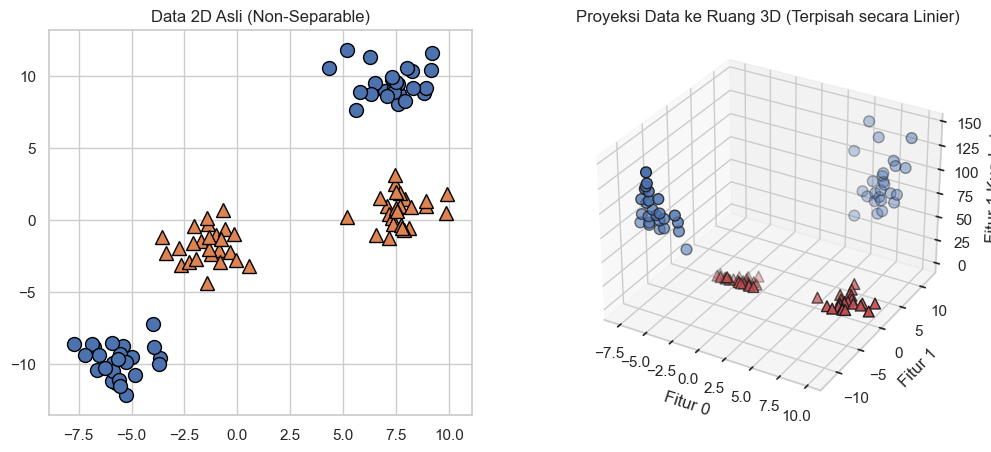

In [14]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs

# Membuat dataset 2D linier non-separable secara sirkuler
X_b, y_b = make_blobs(centers=4, random_state=8)
y_b = y_b % 2

# Tambahkan fitur kuadrat ketiga untuk membuatnya terpisah secara linier di dimensi 3D
X_b_3d = np.hstack([X_b, X_b[:, 1:] ** 2])

fig = plt.figure(figsize=(12, 5))
# Plot 2D Asli
ax1 = fig.add_subplot(121)
mglearn.discrete_scatter(X_b[:, 0], X_b[:, 1], y_b, ax=ax1)
ax1.set_title("Data 2D Asli (Non-Separable)")

# Plot 3D hasil proyeksi kuadrat
ax2 = fig.add_subplot(122, projection='3d')
mask = (y_b == 0)
ax2.scatter(X_b_3d[mask, 0], X_b_3d[mask, 1], X_b_3d[mask, 2], c='b', cmap=mglearn.cm2, s=60, edgecolor='k')
ax2.scatter(X_b_3d[~mask, 0], X_b_3d[~mask, 1], X_b_3d[~mask, 2], c='r', marker='^', cmap=mglearn.cm2, s=60, edgecolor='k')
ax2.set_xlabel("Fitur 0")
ax2.set_ylabel("Fitur 1")
ax2.set_zlabel("Fitur 1 Kuadrat")
ax2.set_title("Proyeksi Data ke Ruang 3D (Terpisah secara Linier)")
plt.show()

In [15]:
# Melatih SVM (RBF Kernel) pada dataset Kanker
model_svm = SVC(C=10, gamma=0.1).fit(X_train_kanker, y_train_kanker)

print("=== SVM Sebelum Fitur Diskala (MinMax) ===")
print(f"Akurasi Latih : {model_svm.score(X_train_kanker, y_train_kanker):.4f}")
print(f"Akurasi Uji   : {model_svm.score(X_test_kanker, y_test_kanker):.4f}")

# Melakukan penskalaan data dengan MinMaxScaler agar semua fitur berada pada rentang 0-1
skaler = MinMaxScaler()
X_train_scaled = skaler.fit_transform(X_train_kanker)
X_test_scaled = skaler.transform(X_test_kanker)

# Latih kembali model SVM menggunakan data skala
model_svm_scaled = SVC(C=10, gamma=0.1).fit(X_train_scaled, y_train_kanker)

print("\n=== SVM Setelah Fitur Diskala (MinMax) ===")
print(f"Akurasi Latih : {model_svm_scaled.score(X_train_scaled, y_train_kanker):.4f}")
print(f"Akurasi Uji   : {model_svm_scaled.score(X_test_scaled, y_test_kanker):.4f}")

=== SVM Sebelum Fitur Diskala (MinMax) ===
Akurasi Latih : 1.0000
Akurasi Uji   : 0.6294

=== SVM Setelah Fitur Diskala (MinMax) ===
Akurasi Latih : 0.9836
Akurasi Uji   : 0.9720


## Bagian 6: Estimasi Ketidakpastian (Uncertainty Estimates)

Pustaka scikit-learn menyediakan dua cara untuk menguji ketidakpastian/kepercayaan dari hasil prediksi klasifikasi:
1. **Decision Function**: Nilai sign kontinu (jarak bertanda ke batas keputusan/hyperplane).
2. **Predict Probability (predict_proba)**: Probabilitas prediksi model dari nilai 0 hingga 1 untuk masing-masing kelas target.

In [16]:
# Melatih model Gradient Boosting Classifier untuk menguji fungsi ketidakpastian
model_gbr = GradientBoostingClassifier(random_state=0).fit(X_train_kanker, y_train_kanker)

# Menampilkan nilai Decision Function & predict_proba untuk 5 sampel pertama data uji
print("=== Decision Function (5 Sampel Pertama) ===")
print(model_gbr.decision_function(X_test_kanker)[:5])

print("\n=== Predict Probability (5 Sampel Pertama) ===")
# Kolom pertama: probabilitas kelas 0 (malignant), kolom kedua: probabilitas kelas 1 (benign)
print(model_gbr.predict_proba(X_test_kanker)[:5])

=== Decision Function (5 Sampel Pertama) ===
[8.68806704 8.74806197 8.32149822 8.77221876 8.42013802]

=== Predict Probability (5 Sampel Pertama) ===
[[1.68557164e-04 9.99831443e-01]
 [1.58743522e-04 9.99841256e-01]
 [2.43172031e-04 9.99756828e-01]
 [1.54955322e-04 9.99845045e-01]
 [2.20335675e-04 9.99779664e-01]]


## Bagian 7: Ringkasan Pipeline Alur Kerja Pembelajaran Terbimbing

Berikut adalah ringkasan alur kerja penuh supervised learning: muat data -> split -> penskalaan -> pelatihan model -> evaluasi model.

In [17]:
# Pipeline lengkap menggunakan SVM (skala data -> fit -> evaluasi)
X_latih, X_uji, y_latih, y_uji = train_test_split(
    kanker.data, kanker.target, random_state=42
)

# Penskalaan fitur secara otomatis
skaler_final = MinMaxScaler()
X_latih_skala = skaler_final.fit_transform(X_latih)
X_uji_skala = skaler_final.transform(X_uji)

# Training SVM dengan skala
svm_final = SVC(C=1.0, kernel='rbf', gamma='scale').fit(X_latih_skala, y_latih)

print(f"Akurasi Akhir Pipeline SVM Ter-skala: {svm_final.score(X_uji_skala, y_uji):.4f}")

Akurasi Akhir Pipeline SVM Ter-skala: 0.9790
